# Part A: Supervised Volatility Forecasting

The goal of Part A is to test whether the market regimes identified in Part B provide useful information for forecasting future realized volatility.

We first build models using standard market variables such as recent realized volatility, VIX, skewness, and kurtosis. We then add the regime information generated by the HMM and compare the forecasting results.

The main question is whether adding regime information improves out-of-sample volatility forecasts.

## 1. Import Libraries

We begin by importing the Python libraries used for data processing, modeling, evaluation, and visualization.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Install parquet
try:
    import pyarrow
except ImportError:
    %pip install pyarrow
    import pyarrow

## 2. Load the Market Data

The analysis uses the merged S&P 500 and VIX dataset created earlier in the project. The dataset contains daily observations from 2000 through 2025.

Before creating the supervised model, we first inspect the available columns and confirm the structure of the dataset.

In [46]:
df = pd.read_parquet("../data/market_2000_2025.parquet")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (6539, 11)

Columns:
['Date', 'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Close', 'SP500_Adj_Close', 'SP500_Volume', 'VIX_Open', 'VIX_High', 'VIX_Low', 'VIX_Close']


,Date,SP500_Open,SP500_High,SP500_Low,SP500_Close,SP500_Adj_Close,SP500_Volume,VIX_Open,VIX_High,VIX_Low,VIX_Close
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,1455.219971,931800000,24.36,26.15,23.98,24.21
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1399.420044,1009000000,24.94,27.18,24.80,27.01
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1402.109985,1085500000,27.98,29.00,25.85,26.41
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1403.449951,1092300000,26.68,26.71,24.70,25.73
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1441.469971,1225200000,25.14,25.17,21.72,21.72


## 3. Identify the Main Market Variables

The merged dataset contains both S&P 500 and VIX data. Because the original datasets can use slightly different column naming conventions, we identify the date, S&P 500 closing price, and VIX closing price before continuing.

In [47]:
# Show columns clearly
for i, col in enumerate(df.columns):
    print(i, col)

0 Date
1 SP500_Open
2 SP500_High
3 SP500_Low
4 SP500_Close
5 SP500_Adj_Close
6 SP500_Volume
7 VIX_Open
8 VIX_High
9 VIX_Low
10 VIX_Close


## 4. Data Preparation

Since this is a time-series forecasting problem, observations must remain in chronological order. We convert the date variable to a datetime format, sort the dataset by date, and remove any duplicate dates.

In [48]:
DATE_COL = "Date"
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

df = (
    df.sort_values(DATE_COL)
      .drop_duplicates(DATE_COL)
      .reset_index(drop=True)
)

print(df[DATE_COL].min())
print(df[DATE_COL].max())
print(df.shape)

df.head()

2000-01-03 00:00:00
2025-12-31 00:00:00
(6539, 11)


,Date,SP500_Open,SP500_High,SP500_Low,SP500_Close,SP500_Adj_Close,SP500_Volume,VIX_Open,VIX_High,VIX_Low,VIX_Close
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,1455.219971,931800000,24.36,26.15,23.98,24.21
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1399.420044,1009000000,24.94,27.18,24.80,27.01
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1402.109985,1085500000,27.98,29.00,25.85,26.41
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1403.449951,1092300000,26.68,26.71,24.70,25.73
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1441.469971,1225200000,25.14,25.17,21.72,21.72


## 5. Calculate Daily Returns

We calculate daily log returns for the S&P 500. These returns are then used to construct realized volatility, skewness, and kurtosis features.

Log returns are used because they are commonly used when working with financial time series.

In [49]:
SP500_CLOSE_COL = "SP500_Close"
df["sp500_return"] = np.log(
    df[SP500_CLOSE_COL] /
    df[SP500_CLOSE_COL].shift(1)
)

df[
    [DATE_COL, SP500_CLOSE_COL, "sp500_return"]
].head(10)

,Date,SP500_Close,sp500_return
0,2000-01-03,1455.219971,NaN
1,2000-01-04,1399.420044,-0.039099
2,2000-01-05,1402.109985,0.001920
3,2000-01-06,1403.449951,0.000955
4,2000-01-07,1441.469971,0.026730
5,2000-01-10,1457.599976,0.011128
6,2000-01-11,1438.560059,-0.013149
7,2000-01-12,1432.250000,-0.004396
8,2000-01-13,1449.680054,0.012096
9,2000-01-14,1465.150024,0.010615


## 6. Create Realized Volatility Features

Recent volatility tends to contain useful information about future volatility.

We therefore calculate trailing realized volatility over 5-day, 10-day, and 20-day windows. The values are annualized using 252 trading days per year.

In [50]:
def realized_volatility(returns, window):
    return returns.rolling(window).std() * np.sqrt(252)


df["rv_5"] = realized_volatility(
    df["sp500_return"],
    5
)

df["rv_10"] = realized_volatility(
    df["sp500_return"],
    10
)

df["rv_20"] = realized_volatility(
    df["sp500_return"],
    20
)

df[
    [
        DATE_COL,
        "sp500_return",
        "rv_5",
        "rv_10",
        "rv_20"
    ]
].tail()

,Date,sp500_return,rv_5,rv_10,rv_20
6534,2025-12-24,0.003216,0.036592,0.114814,0.091265
6535,2025-12-26,-0.000304,0.054248,0.114612,0.088877
6536,2025-12-29,-0.003498,0.062972,0.099724,0.088496
6537,2025-12-30,-0.001377,0.052562,0.099560,0.086169
6538,2025-12-31,-0.007385,0.062311,0.107402,0.090352


## 7. Create VIX Features

The VIX represents the market's expectation of near-term volatility and is likely to be an important predictor of future realized volatility.

We use both the VIX level and its daily percentage change as model inputs.

In [51]:
VIX_CLOSE_COL = "VIX_Close"
df["vix"] = df[VIX_CLOSE_COL]

df["vix_change"] = (
    df["vix"]
    .pct_change()
)

df[
    [
        DATE_COL,
        "vix",
        "vix_change"
    ]
].tail()

,Date,vix,vix_change
6534,2025-12-24,13.47,-0.037857
6535,2025-12-26,13.60,0.009651
6536,2025-12-29,14.20,0.044118
6537,2025-12-30,14.33,0.009155
6538,2025-12-31,14.95,0.043266


## 8. Create Return Distribution Features

Volatility alone may not fully describe recent market behavior.

We therefore calculate rolling skewness and kurtosis using a 20-day window. These variables help capture changes in the shape of the recent return distribution.

In [52]:
df["skew_20"] = (
    df["sp500_return"]
    .rolling(20)
    .skew()
)

df["kurtosis_20"] = (
    df["sp500_return"]
    .rolling(20)
    .kurt()
)

df[
    [
        DATE_COL,
        "skew_20",
        "kurtosis_20"
    ]
].tail()

,Date,skew_20,kurtosis_20
6534,2025-12-24,-0.907484,0.344626
6535,2025-12-26,-0.830229,0.406201
6536,2025-12-29,-0.634481,0.170786
6537,2025-12-30,-0.741555,0.620676
6538,2025-12-31,-0.518442,-0.100445


## 9. Define the Forecasting Target

The supervised learning target is 5-day forward realized volatility.

For each trading day, the target is calculated using S&P 500 returns over the following five trading days. All predictor variables, however, use information available on or before the current date.

This separation is important because it prevents future market information from directly entering the predictor variables.

In [53]:
forward_squared_returns = (
    df["sp500_return"].shift(-1).pow(2)
    + df["sp500_return"].shift(-2).pow(2)
    + df["sp500_return"].shift(-3).pow(2)
    + df["sp500_return"].shift(-4).pow(2)
    + df["sp500_return"].shift(-5).pow(2)
)

df["target_rv_5"] = np.sqrt(
    (252 / 5) *
    forward_squared_returns
)

df[
    [
        DATE_COL,
        "rv_5",
        "target_rv_5"
    ]
].tail(10)

,Date,rv_5,target_rv_5
6529,2025-12-17,0.095732,0.103283
6530,2025-12-18,0.126356,0.086742
6531,2025-12-19,0.133648,0.065240
6532,2025-12-22,0.138836,0.047720
6533,2025-12-23,0.134278,0.063142
6534,2025-12-24,0.036592,NaN
6535,2025-12-26,0.054248,NaN
6536,2025-12-29,0.062972,NaN
6537,2025-12-30,0.052562,NaN
6538,2025-12-31,0.062311,NaN


## 10. Inspect the Engineered Features

Before modeling, we inspect the engineered variables and summary statistics to make sure the values are reasonable and that there are no unexpected data issues.

In [54]:
feature_check = [
    "sp500_return",
    "rv_5",
    "rv_10",
    "rv_20",
    "vix",
    "vix_change",
    "skew_20",
    "kurtosis_20",
    "target_rv_5"
]

df[feature_check].describe().T

df[feature_check].isna().sum()

sp500_return     1
rv_5             5
rv_10           10
rv_20           20
vix              0
vix_change       1
skew_20         20
kurtosis_20     20
target_rv_5      5
dtype: int64

## 11. Current and Future Realized Volatility

Before fitting the models, we compare recent 5-day realized volatility with our 5-day forward realized volatility target.

This provides a simple visual check of volatility persistence, which is also the motivation for using current realized volatility as our baseline forecast.

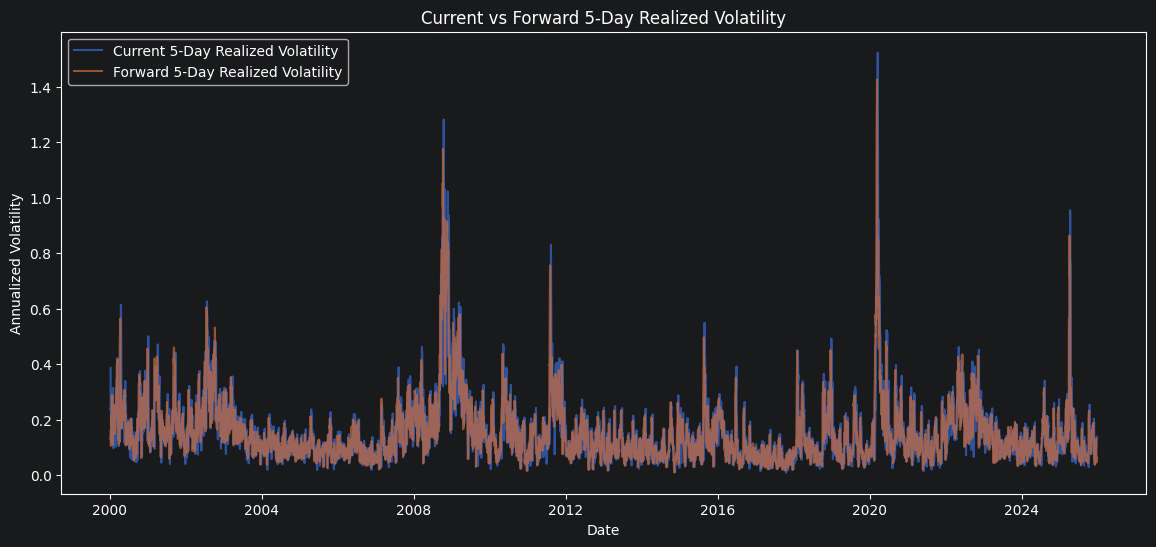

In [55]:
plot_df = df.dropna(
    subset=["rv_5", "target_rv_5"]
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df[DATE_COL],
    plot_df["rv_5"],
    label="Current 5-Day Realized Volatility",
    alpha=0.7
)

plt.plot(
    plot_df[DATE_COL],
    plot_df["target_rv_5"],
    label="Forward 5-Day Realized Volatility",
    alpha=0.7
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title(
    "Current vs Forward 5-Day Realized Volatility"
)

plt.legend()
plt.show()

## 12. Add Market Regime Information from Part B

Part B uses a Hidden Markov Model to identify latent market regimes.

For Part A, the regime information is added as an additional predictor. This allows us to compare otherwise similar models with and without HMM-derived regime information.

The purpose of this comparison is to determine whether the inferred market state contains predictive information beyond standard observable market variables.

## 12. Add Market Regime Information from Part B

Part B uses a Hidden Markov Model to identify latent market regimes.

For Part A, the regime information is added as an additional predictor. This allows us to compare otherwise similar models with and without HMM-derived regime information.

The purpose of this comparison is to determine whether the inferred market state contains predictive information beyond standard observable market variables.

In [56]:
part_b = pd.read_parquet(
    "../data/model_b_hmm_full_output.parquet"
)


part_b["Date"] = pd.to_datetime(
    part_b["Date"]
)

# Remove overlapping columns from part_b, except the merge key
overlap_cols = [
    col for col in part_b.columns
    if col in df.columns and col != "Date"
]

part_b_clean = part_b.drop(columns=overlap_cols)

df_merged = pd.merge(
    df,
    part_b_clean,
    on="Date",
    how="inner"
)

print(df_merged.shape)
print(df_merged.columns.tolist())

df_merged = pd.merge(
    df,
    part_b,
    on="Date",
    how="inner"
)

df_merged.head()

df_merged[
    [
        "P_Calm",
        "P_Transition",
        "P_Stressed",
      #  "Probability_Sum"
    ]
].describe()

(6519, 31)
['Date', 'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Close', 'SP500_Adj_Close', 'SP500_Volume', 'VIX_Open', 'VIX_High', 'VIX_Low', 'VIX_Close', 'sp500_return', 'rv_5', 'rv_10', 'rv_20', 'vix', 'vix_change', 'skew_20', 'kurtosis_20', 'target_rv_5', 'VIX_Level', 'VIX_Change', 'Realized_Vol_20D', 'Return_Skew_20D', 'Return_Kurt_20D', 'HMM_State', 'Regime', 'P_Calm', 'P_Transition', 'P_Stressed', 'Regime_Confidence']


,P_Calm,P_Transition,P_Stressed
count,6.519000e+03,6.519000e+03,6.519000e+03
mean,3.380678e-01,4.158252e-01,2.461069e-01
std,4.626036e-01,4.765268e-01,4.193987e-01
min,0.000000e+00,7.198153e-115,4.509488e-80
25%,5.157020e-12,3.412452e-06,5.395355e-07
50%,1.331436e-05,5.885168e-03,1.799650e-05
75%,9.995771e-01,9.997921e-01,3.434855e-01
max,1.000000e+00,1.000000e+00,1.000000e+00


## 13. Define the Predictor Sets

To test whether regime information improves volatility forecasting, we create two predictor sets.

The base predictor set contains only observable market variables. The regime-enhanced predictor set contains exactly the same variables plus the probabilities generated by the HMM.

This provides a direct comparison of forecasting performance with and without regime information.

In [68]:
base_features = [
    "rv_5",
    "rv_10",
    "rv_20",
    "target_rv_5",
    "VIX_Level",
    "VIX_Change",
    "Return_Skew_20D",
    "Return_Kurt_20D"
]


regime_features = base_features + [
    "P_Calm",
    "P_Transition",
    "P_Stressed"
]


print("Base features:")

for feature in base_features:
    print("-", feature)


print("\nRegime-enhanced features:")

for feature in regime_features:
    print("-", feature)

Base features:
- rv_5
- rv_10
- rv_20
- target_rv_5
- VIX_Level
- VIX_Change
- Return_Skew_20D
- Return_Kurt_20D

Regime-enhanced features:
- rv_5
- rv_10
- rv_20
- target_rv_5
- VIX_Level
- VIX_Change
- Return_Skew_20D
- Return_Kurt_20D
- P_Calm
- P_Transition
- P_Stressed


## 14. Create the Modeling Dataset

Rolling calculations create missing observations at the beginning of the sample, while the forward volatility target creates missing values at the end.

We remove these observations, as well as any infinite values, before estimating the supervised models.

In [69]:
required_columns = [
    "Date",
    "Regime",
    "HMM_State",
    "Regime_Confidence"
] + regime_features

print(df_merged.columns)
model_df = (
    df_merged[required_columns]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .copy()
)


print(
    "Original observations:",
    len(df)
)

print(
    "Final model observations:",
    len(model_df)
)

print(
    "Date range:",
    model_df["Date"].min(),
    "to",
    model_df["Date"].max()
)


model_df.head()

Index(['Date', 'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Close_x',
       'SP500_Adj_Close', 'SP500_Volume', 'VIX_Open', 'VIX_High', 'VIX_Low',
       'VIX_Close', 'sp500_return', 'rv_5', 'rv_10', 'rv_20', 'vix',
       'vix_change', 'skew_20', 'kurtosis_20', 'target_rv_5', 'SP500_Close_y',
       'VIX_Level', 'VIX_Change', 'Realized_Vol_20D', 'Return_Skew_20D',
       'Return_Kurt_20D', 'HMM_State', 'Regime', 'P_Calm', 'P_Transition',
       'P_Stressed', 'Regime_Confidence'],
      dtype='object')
Original observations: 6539
Final model observations: 6514
Date range: 2000-02-01 00:00:00 to 2025-12-23 00:00:00


,Date,Regime,HMM_State,Regime_Confidence,rv_5,rv_10,rv_20,target_rv_5,VIX_Level,VIX_Change,Return_Skew_20D,Return_Kurt_20D,P_Calm,P_Transition,P_Stressed
0,2000-02-01,Transition,2,1.000000,0.311527,0.254833,0.263633,0.117539,23.45,-1.50,-0.523001,0.454056,0.000000e+00,1.000000,4.509488e-80
1,2000-02-02,Transition,2,0.999909,0.309467,0.254593,0.223332,0.190041,23.12,-0.33,-0.218100,0.560588,2.356238e-10,0.999909,9.093237e-05
2,2000-02-03,Transition,2,0.999921,0.313723,0.263269,0.226596,0.174558,22.01,-1.11,-0.291496,0.391489,8.857389e-11,0.999921,7.901573e-05
3,2000-02-04,Transition,2,0.999936,0.164929,0.263174,0.226637,0.230427,21.54,-0.47,-0.275308,0.381911,4.198119e-10,0.999936,6.384705e-05
4,2000-02-07,Transition,2,0.999986,0.096485,0.216664,0.204786,0.230877,22.79,1.25,-0.503579,0.804882,2.688458e-10,0.999986,1.432520e-05


## 15. Train, Validation, and Test Periods

Because this is a time-series forecasting problem, observations are kept in chronological order rather than randomly shuffled.

The sample is divided into:

- Training: before 2019
- Validation: 2019 through 2021
- Test: 2022 through 2025

This ensures that the final model evaluation is performed using observations occurring after the data used for model estimation.

In [70]:
train = model_df[
    model_df["Date"] < "2019-01-01"
].copy()


validation = model_df[
    (
        model_df["Date"]
        >= "2019-01-01"
    )
    &
    (
        model_df["Date"]
        < "2022-01-01"
    )
].copy()


test = model_df[
    model_df["Date"]
    >= "2022-01-01"
].copy()


print(
    "TRAIN:",
    len(train),
    "|",
    train["Date"].min(),
    "to",
    train["Date"].max()
)


print(
    "VALIDATION:",
    len(validation),
    "|",
    validation["Date"].min(),
    "to",
    validation["Date"].max()
)


print(
    "TEST:",
    len(test),
    "|",
    test["Date"].min(),
    "to",
    test["Date"].max()
)

TRAIN: 4759 | 2000-02-01 00:00:00 to 2018-12-31 00:00:00
VALIDATION: 757 | 2019-01-02 00:00:00 to 2021-12-31 00:00:00
TEST: 998 | 2022-01-03 00:00:00 to 2025-12-23 00:00:00


## 17. Evaluation Metrics

Forecasting performance is evaluated using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).

RMSE places greater weight on large forecast errors, while MAE measures the average absolute difference between predicted and realized volatility.

Lower values indicate better forecasting performance.

In [66]:
def evaluate_model(
    y_true,
    y_pred
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    return {
        "RMSE": rmse,
        "MAE": mae
    }

## 16. Inspect the Forecasting Target

The supervised learning target is 5-day forward realized volatility.

Before fitting the models, we inspect the target variable and its behavior through time. Periods of market stress are expected to produce much higher realized volatility than normal periods.

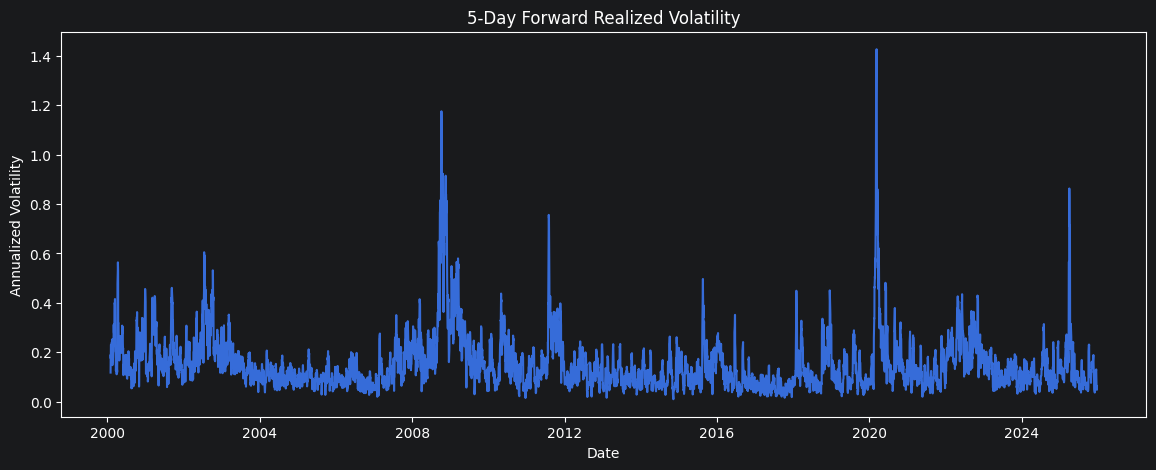

In [72]:
model_df["target_rv_5"].describe()

plt.figure(figsize=(14, 5))

plt.plot(
    model_df["Date"],
    model_df["target_rv_5"]
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("5-Day Forward Realized Volatility")

plt.show()

## 19. Persistence Baseline

Volatility tends to persist over short horizons. A simple benchmark is therefore to assume that volatility over the next five trading days will be similar to volatility over the most recent five trading days.

This provides a useful baseline against which the supervised models can be compared.

In [73]:
y_train = train["target_rv_5"]
y_validation = validation["target_rv_5"]
y_test = test["target_rv_5"]

test["Prediction_Persistence"] = test["rv_5"]

persistence_results = evaluate_model(
    y_test,
    test["Prediction_Persistence"]
)

print("Persistence baseline:")
print(persistence_results)

Persistence baseline:
{'RMSE': np.float64(0.09196900753530432), 'MAE': 0.06059956292604514}


## 20. Ridge Regression Without Regime Information

The first supervised model is Ridge regression using only observable market variables.

Ridge provides a relatively simple linear model while regularization helps reduce instability caused by correlated predictors, particularly the different realized-volatility windows.

In [74]:
X_train_base = train[base_features]
X_validation_base = validation[base_features]
X_test_base = test[base_features]

scaler_base = StandardScaler()

X_train_base_scaled = scaler_base.fit_transform(
    X_train_base
)

X_validation_base_scaled = scaler_base.transform(
    X_validation_base
)

X_test_base_scaled = scaler_base.transform(
    X_test_base
)

ridge_base = Ridge(alpha=1.0)

ridge_base.fit(
    X_train_base_scaled,
    y_train
)

pred_ridge_base = ridge_base.predict(
    X_test_base_scaled
)

ridge_base_results = evaluate_model(
    y_test,
    pred_ridge_base
)

print("Ridge without regime information:")
print(ridge_base_results)

Ridge without regime information:
{'RMSE': np.float64(4.038896736586025e-05), 'MAE': 2.6392754433166835e-05}


## 21. Ridge Regression With Regime Information

We next estimate the same Ridge regression model after adding the Calm, Transition, and Stressed HMM probabilities.

Since the observable market variables remain unchanged, the difference in forecasting performance helps measure whether regime information provides additional predictive value.

In [75]:
X_train_regime = train[regime_features]
X_validation_regime = validation[regime_features]
X_test_regime = test[regime_features]

scaler_regime = StandardScaler()

X_train_regime_scaled = scaler_regime.fit_transform(
    X_train_regime
)

X_validation_regime_scaled = scaler_regime.transform(
    X_validation_regime
)

X_test_regime_scaled = scaler_regime.transform(
    X_test_regime
)

ridge_regime = Ridge(alpha=1.0)

ridge_regime.fit(
    X_train_regime_scaled,
    y_train
)

pred_ridge_regime = ridge_regime.predict(
    X_test_regime_scaled
)

ridge_regime_results = evaluate_model(
    y_test,
    pred_ridge_regime
)

print("Ridge with regime information:")
print(ridge_regime_results)

Ridge with regime information:
{'RMSE': np.float64(4.061844504062573e-05), 'MAE': 2.6568473757874362e-05}


## 24. Model Comparison

The table below summarizes out-of-sample forecasting performance for the persistence benchmark, Ridge regression, and XGBoost.

For Ridge and XGBoost, we compare a base model using only observable market variables with a regime-enhanced model that also includes the HMM probabilities.

The main question is whether forecast error decreases when regime information is included.

In [79]:
results = pd.DataFrame([
    {
        "Model": "Persistence",
        "Regime Information": "No",
        **persistence_results
    },
    {
        "Model": "Ridge",
        "Regime Information": "No",
        **ridge_base_results
    },
    {
        "Model": "Ridge",
        "Regime Information": "Yes",
        **ridge_regime_results
    }
])

results = (
    results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results.round(9)

,Model,Regime Information,RMSE,MAE
0,Ridge,No,0.000040,0.000026
1,Ridge,Yes,0.000041,0.000027
2,Persistence,No,0.091969,0.060600


## 25. Incremental Value of Regime Information

To make the effect of the HMM variables easier to interpret, we calculate the percentage reduction in RMSE and MAE after adding the regime probabilities.

A positive value indicates an improvement in forecasting accuracy, while a negative value indicates that forecast error increased.

In [81]:
ridge_rmse_improvement = (
    (
        ridge_base_results["RMSE"]
        - ridge_regime_results["RMSE"]
    )
    / ridge_base_results["RMSE"]
    * 100
)

ridge_mae_improvement = (
    (
        ridge_base_results["MAE"]
        - ridge_regime_results["MAE"]
    )
    / ridge_base_results["MAE"]
    * 100
)


print(
    f"Ridge RMSE improvement: "
    f"{ridge_rmse_improvement:.2f}%"
)

print(
    f"Ridge MAE improvement: "
    f"{ridge_mae_improvement:.2f}%"
)

print()



Ridge RMSE improvement: -0.57%
Ridge MAE improvement: -0.67%

